# DX 704 Week 13 Project

This week's project will build a simple agent using language models and tools.
You will integrate the Gemini language model API with custom tools that you create to assist in task automation.


The full project description and a template notebook are available on GitHub: [Project 13 Materials](https://github.com/bu-cds-dx704/dx704-project-13).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 0: Gemini Tool Example

Review the code and its output below to get an idea for how the Gemini API uses tools.

* https://ai.google.dev/gemini-api/docs/tools
* https://ai.google.dev/gemini-api/docs/function-calling

In [1]:
%pip install -q google-genai genanki

Note: you may need to restart the kernel to use updated packages.


In [2]:
import hashlib

import genanki
import matplotlib.pyplot as plt

from google             import genai
from google.genai       import types
# from google.colab import userdata

In [4]:
# # import GEMINI_API_KEY from file api_key.txt

MY_API_KEY = open("api_key.txt").read().split("=")[1].strip().strip('"').strip("'")
client      = genai.Client(api_key = MY_API_KEY)  

model_name  = 'gemini-2.5-flash' #'gemini-2.5-flash'

In [5]:
for model in client.models.list():
    print(f"Model Name: {model.name}")

Model Name: models/gemini-2.5-flash
Model Name: models/gemini-2.5-pro
Model Name: models/gemini-2.0-flash
Model Name: models/gemini-2.0-flash-001
Model Name: models/gemini-2.0-flash-lite-001
Model Name: models/gemini-2.0-flash-lite
Model Name: models/gemini-2.5-flash-preview-tts
Model Name: models/gemini-2.5-pro-preview-tts
Model Name: models/gemma-3-1b-it
Model Name: models/gemma-3-4b-it
Model Name: models/gemma-3-12b-it
Model Name: models/gemma-3-27b-it
Model Name: models/gemma-3n-e4b-it
Model Name: models/gemma-3n-e2b-it
Model Name: models/gemma-4-26b-a4b-it
Model Name: models/gemma-4-31b-it
Model Name: models/gemini-flash-latest
Model Name: models/gemini-flash-lite-latest
Model Name: models/gemini-pro-latest
Model Name: models/gemini-2.5-flash-lite
Model Name: models/gemini-2.5-flash-image
Model Name: models/gemini-3-pro-preview
Model Name: models/gemini-3-flash-preview
Model Name: models/gemini-3.1-pro-preview
Model Name: models/gemini-3.1-pro-preview-customtools
Model Name: model

In [4]:
# Rate limit documentation https://ai.google.dev/gemini-api/docs/rate-limits

In [5]:
change_light_array_function = {
    "name": "change_light_array",
    "description": "Change the color of a light in a 64x64 array of LEDs.",
    "parameters": {
        "type": "object",
        "properties": {
            "red": {"type": "integer", "description": "Red value of the color."},
            "green": {"type": "integer", "description": "Green value of the color."},
            "blue": {"type": "integer", "description": "Blue value of the color."},
            "x": {"type": "integer", "description": "X coordinate of the light. Must be between 0 and 63 inclusive."},
            "y": {"type": "integer", "description": "Y coordinate of the light. Must be between 0 and 63 inclusive."},
        },
        "required": ["red", "green", "blue"],
    }
}

In [6]:
light_tools     = types.Tool(function_declarations=[change_light_array_function])
light_config    = types.GenerateContentConfig(tools=[light_tools])

In [7]:
light_response = client.models.generate_content(
    contents    = "Set the light at 3,3 to be chartreuse.",
    config      = light_config,
    model       = model_name
)
light_response

GenerateContentResponse(
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            function_call=FunctionCall(
              args=<... Max depth ...>,
              name=<... Max depth ...>
            ),
            thought_signature=b"\n\xbb\x06\x01\x0c9\xd6\xc7\xc37\xe2\xa2F\xa9\xbc\xea\x03Dt\x1f\x1dkII7\x81\n\xb4\x12\xa8\x84:m\xa1\xfe\xeep\xfe\xa2\xfb\xb1u\xc3\xf1\xda\xaf\x01\xe9\r\nu\x9e2\x8d\xb9r\xbbHp\xe2\xe3\x9b\xa5\xea\xf62\x95\x9e\x9a\x8c\\5N@\x8c\xf9\xc5G\x98#\xad\x81\x12\xa9\xd9\xc0\xbd\xa7'\xa7\xc2\xf1BM\xc3a\xae...'
          ),
        ],
        role='model'
      ),
      finish_reason=<FinishReason.STOP: 'STOP'>,
      index=0
    ),
  ],
  model_version='gemini-2.5-flash',
  response_id='8IbqacLAPMq-_uMPhcTM2Q8',
  sdk_http_response=HttpResponse(
    headers=<dict len=12>
  ),
  usage_metadata=GenerateContentResponseUsageMetadata(
    candidates_token_count=41,
    prompt_token_count=165,
    prompt_tokens_details=[
      Modali

In [8]:
light_response.candidates[0].content.parts[0].function_call

FunctionCall(
  args={
    'blue': 0,
    'green': 255,
    'red': 127,
    'x': 3,
    'y': 3
  },
  name='change_light_array'
)

## Part 1: Implement Agent Logging

The Agent class below uses the Gemini API's tool support to provide a chat interface that can use tools.
Modify the Agent class to save a transcript with the name `AGENT_NAME.txt` where `AGENT_NAME` is the name used when creating the Agent object.
Anything in the `contents` list inside the `run` method should be saved to that file.
Test your code with the `plain_agent` setup below.

Submit "plain.txt" in Gradescope.

In [9]:
class Agent(object):
    def __init__(self, name, introduction, prompt, model="gemini-2.5-flash"):
        self.name           = name
        self.introduction   = introduction
        self.prompt         = prompt
        self.model          = model

        self.function_declarations = {}
        self.functions = {}

    def predict(self, contents, **kwargs):
        kwargs.setdefault('model', self.model)

        return client.models.generate_content(contents=contents, **kwargs)

    def register_tool(self, function, **function_declaration):
        if "name" not in function_declaration:
            function_declaration["name"] = function.__name__

        function_name = function_declaration["name"]
        assert "description" in function_declaration
        assert "parameters" in function_declaration

        self.function_declarations[function_name]   = function_declaration
        self.functions[function_name]               = function

    def run(self):
        print("RUNNING WITH TOOLS", list(self.functions.keys()))
        tools   = types.Tool(function_declarations=list(self.function_declarations.values()))
        config  = types.GenerateContentConfig(tools=[tools])

        print(self.introduction, "\n\n")

# The contents list, which holds the complete conversation transcript, only exists within the scope of the run method.
# transcript is only complete after the user stops the conversation (i.e., after the while True loop breaks).
# file writing logic needs to be placed at the very end of the existing run method,
        contents = []
        while True:
            p = input("> ")
            if p.strip().lower() in ("stop", "quit", "exit"):
                break

            contents.append(p)
            response = self.predict(
                contents    = contents,
                config      = config
            )

            for new_content_part in response.candidates[0].content.parts:
                if new_content_part.text:
                    print("TEXT", new_content_part.text)
                    contents.append(new_content_part.text)
                elif new_content_part.function_call:
                    call = new_content_part.function_call
                    print("FUNCTION CALL", call)
                    if call.name in self.functions:
                        output = self.functions[call.name](**call.args)
                        if output:
                            print("OUTPUT", output)
                            contents.append(output)
                    else:
                        print("UNRECOGNIZED FUNCTION", call.name)
                else:
                    print("UNKNOWN", new_content_part)

        # YOUR CHANGES HERE
        with open(f"{self.name}.txt", "w") as file:  # file.write('\n\n'.join(contents)
            for item in contents:
                file.write(f"{item}\n")


In [10]:
plain_agent = Agent(name            = "plain",
                    introduction    = "Hi, I am PlainGPT and I have no tools.",
                    prompt          = "You are a helpful agent that is eager to help but you have no tools.",
                    model           = "gemini-2.5-flash")

In [39]:
plain_agent.run()

RUNNING WITH TOOLS []
Hi, I am PlainGPT and I have no tools. 


TEXT First, let me tell you something absolutely crucial: **You are NOT stupid.**

Feeling like you're stupid is a common human experience, especially when you're facing challenges, learning something new, or comparing yourself to others. But intelligence isn't a fixed, unchangeable trait. It's a dynamic capacity that can grow and develop throughout your life, much like a muscle. What you're experiencing is likely a desire to learn, grow, and improve your understanding of the world, which is actually a very smart impulse!

So, let's reframe this. You want to enhance your cognitive abilities, broaden your knowledge, and develop more effective ways of thinking and problem-solving. That's fantastic! Here’s a roadmap to becoming "smarter" – which really means becoming a more effective, curious, and knowledgeable learner:

---

### Phase 1: Mindset & Foundation

This is the most important step. Your beliefs about your own intel

KeyboardInterrupt: 

## Part 2: Test the Agent Code

Use the color agent below and instruct the agent to show you the colors blue, red, and cyan.
After the agent has shown those colors, make sure to end the `run` method cleanly by telling the agent stop, quit, or exit.


You will notice that the language model's behavior is different from other language models or even normal Gemini since it is working with a restricted set of tools.
You may change the agent code if you wish (e.g. to change the model or give it more tools), but be careful not to change the information stored to the contents list and the log file.


Hint: The RGB values for blue are (0, 0, 255), the RGB values for red are (255, 0, 0) and the RGB values for cyan are (0, 255, 255).
The auto-grader will be checking for those values in your log file, so make sure that the agent shows you the right colors.
Ideally, you can get it to figure out those values on its own, but in the worst case you can tell the agent the RGB values.

Submit "`color.txt`" in Gradescope.

In [11]:
def show_color(red, green, blue):
    plt.imshow([[[red, green, blue]]])
    plt.axis('off')
    plt.show()
    return f"Red: {red}, Green: {green}, Blue: {blue}"

color_agent = Agent(name            = "color",
                    introduction    = "Hi, I am ColorGPT and I know every color.",
                    prompt          = "You are a helpful agent that is eager to show off your color knowledge.",
                    model           = "gemini-2.5-pro")
color_agent.register_tool(show_color,
                          description = "Show a color!",
                          parameters = {"type": "object",
                                         "properties": {
                                             "red": {"type": "integer", "description": "Red value of the color."},
                                             "green": {"type": "integer", "description": "Green value of the color."},
                                             "blue": {"type": "integer", "description": "Blue value of the color."}
                                         }, "required": ["red", "green", "blue"]})

RUNNING WITH TOOLS ['show_color']
Hi, I am ColorGPT and I know every color. 


TEXT I can do that. I can show you the color purple, is that okay?
FUNCTION CALL id=None args={'green': 0, 'red': 128, 'blue': 128} name='show_color' partial_args=None will_continue=None


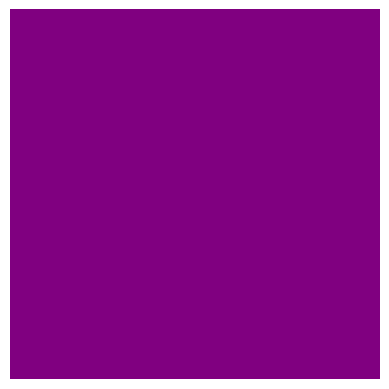

In [ ]:
color_agent.run()

## Part 3: Modify Anki Flashcard Agent

[Anki](https://apps.ankiweb.net/) is a program to help memorization using Flashcards.
(Professor Considine uses Anki to learn foreign language vocabulary.)
The agent that follows can create an Anki "deck" and add notes to create flashcards.
However, the save functionality has not yet been integrated as a tool for the agent.
Implement that functionality and then test it by instructing the agent to save an empty deck as "`empty.apkg`".

Submit "empty.apkg" in Gradescope.

In [78]:
# Simple Model setup from https://github.com/kerrickstaley/genanki?tab=readme-ov-file#models
# this defines a model of flashcards with just two fields, question for the front, and answer for the back.

simple_model = genanki.Model(
    model_id = 1607392319,
    name     = 'Simple Model',
    fields = [
        {'name': 'Question'},
        {'name': 'Answer'},
    ],
    templates = [
        {
        'name': 'Card 1',
        'qfmt': '{{Question}}',
        'afmt': '{{FrontSide}}<hr id="answer">{{Answer}}',
        },
    ])

In [79]:
anki_decks = {}

In [80]:
def get_deck(deck_name):
    if deck_name not in anki_decks:
        hash                  = hashlib.sha256(deck_name.encode('utf-8')).hexdigest()
        hash                  = hash[:12]
        hash                  = int(hash, 16)
        anki_decks[deck_name] = genanki.deck.Deck(deck_id=hash, name=deck_name)
        anki_decks[deck_name].add_model(simple_model)

    return anki_decks[deck_name]

get_deck("test")

In [81]:
anki_agent = Agent(name         = "anki",
                   introduction = "Hi, I am AnkiGPT and I can help you build Anki flashcard decks.",
                   prompt       = "You are a helpful AI that helps look up content for flashcards and then makes the flashcards.")

In [82]:
def create_anki_note(front, back, deck):
    get_deck(deck).add_note(genanki.Note(model = simple_model, fields = [front, back]))
    return f"Created note in Anki deck {deck!r}"

anki_agent.register_tool(create_anki_note,
    description = "Create a note in an Anki flashcard deck.",
    parameters  = {
        "type": "object",
        "properties": {
            "front":    {"type": "string", "description": "Content for front side of flash card."},
            "back":     {"type": "string", "description": "Content for back side of flash card."},
            "deck":     {"type": "string", "description": "Name of the Anki deck to add the note to."},
        },
        "required": ["front", "back", "deck"],
    }
)


In [83]:
def save_anki_deck(deck):
    genanki.Package(get_deck(deck)).write_to_file(f"{deck}.apkg")
    return f"Saved Anki deck {deck!r} to file."
# the conversion flag !r inside the f-string forces Python to call repr(deck) instead of str(deck). 

In [ ]:
# YOUR CHANGES HERE
anki_agent.register_tool(
    save_anki_deck,
    description = "Save an Anki flashcard deck to a file.",
    parameters = {
        "type": "object",
        "properties": {
            "deck": {
                "type": "string",
                "description": "Name of the Anki deck to save."
            },
        },
        "required": ["deck"]
    }
)


In [45]:
anki_decks

{'test': <genanki.deck.Deck at 0x11d8fcb10>}

In [88]:
anki_agent.run()

RUNNING WITH TOOLS ['create_anki_note', 'save_anki_deck']
Hi, I am AnkiGPT and I can help you build Anki flashcard decks. 


TEXT I can save an empty Anki deck for you. What would you like to name the deck?
FUNCTION CALL id=None args={'deck': 'empty'} name='save_anki_deck'
OUTPUT Saved Anki deck 'empty' to file.
FUNCTION CALL id=None args={'deck': 'empty_2'} name='save_anki_deck'
OUTPUT Saved Anki deck 'empty_2' to file.


## Part 4: Make an Anki Deck with Flashcards

Run the Anki agent again, and instruct it to make 10 flashcards on a topic of your choice.
If possible, have the agent supply the answers to your questions.
When you are done, save the deck with an appropriate name (but not "empty.apkg").

Submit "`anki.txt`" from making flashcards and the .apkg file with your flashcards in Gradescope.

In [86]:
anki_agent.run()

RUNNING WITH TOOLS ['create_anki_note', 'save_anki_deck']
Hi, I am AnkiGPT and I can help you build Anki flashcard decks. 


FUNCTION CALL id=None args={'front': 'What is Machine Learning?', 'deck': 'my_deck', 'back': 'A field of study that gives computers the ability to learn without being explicitly programmed.'} name='create_anki_note'
OUTPUT Created note in Anki deck 'my_deck'
FUNCTION CALL id=None args={'back': 'A type of machine learning where the model is trained on labeled data.', 'front': 'What is Supervised Learning?', 'deck': 'my_deck'} name='create_anki_note'
OUTPUT Created note in Anki deck 'my_deck'
FUNCTION CALL id=None args={'back': 'A type of machine learning where the model is trained on unlabeled data, trying to find patterns or structures.', 'deck': 'my_deck', 'front': 'What is Unsupervised Learning?'} name='create_anki_note'
OUTPUT Created note in Anki deck 'my_deck'
FUNCTION CALL id=None args={'back': 'A type of supervised learning problem where the output variabl

## Part 5: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.
You do not need to provide code for data collection if you did that by manually.

## Part 6: Acknowledgements

If you discussed this assignment with anyone, please acknowledge them here.
If you did this assignment completely on your own, simply write none below.

If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for. If you did not use any other libraries, simply write none below.

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy. If you did not use any generative AI tools, simply write none below.